In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [3]:
zip_path = "titanic.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    with zip_ref.open("train.csv") as file:
        df = pd.read_csv(file)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
df.info()

Shape: (891, 12)

Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        8

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


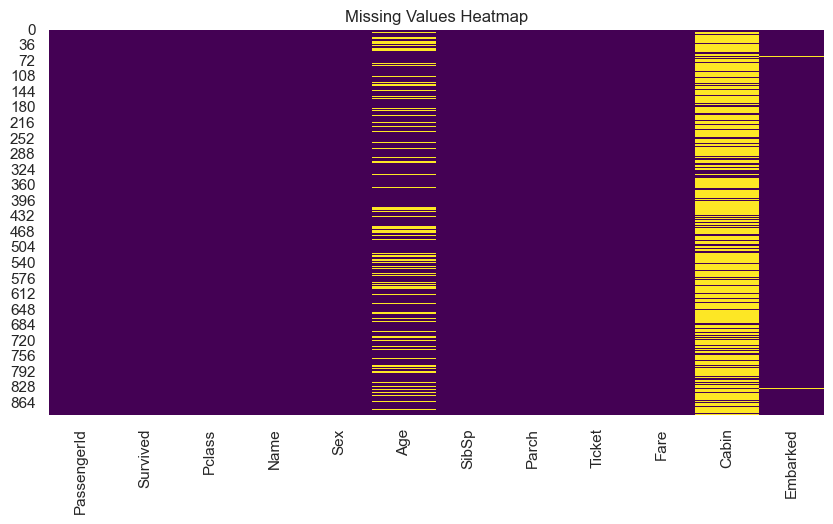

In [7]:
print(df.isnull().sum())

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
# Fill missing Age values
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column because it has many missing values
df.drop("Cabin", axis=1, inplace=True)

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


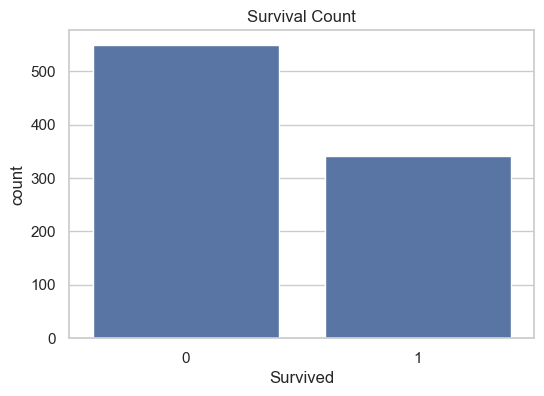

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Survived")
plt.title("Survival Count")
plt.show()

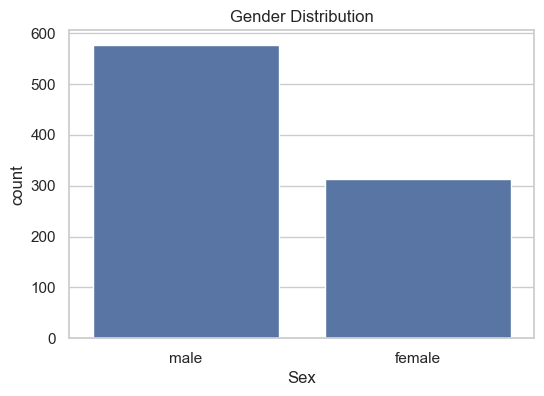

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Sex")
plt.title("Gender Distribution")
plt.show()

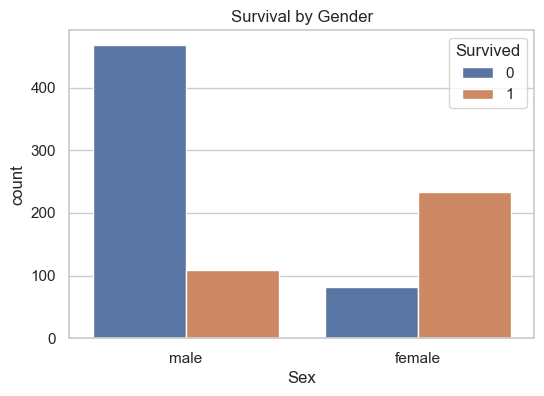

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.show()

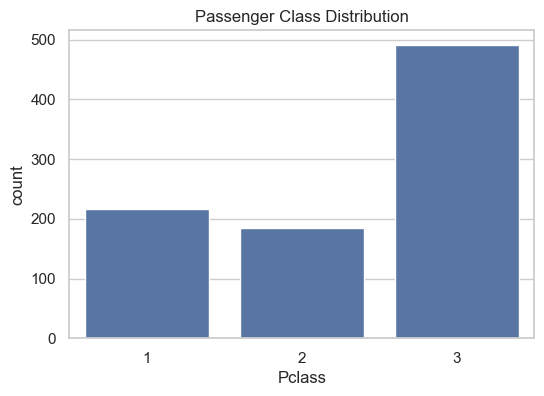

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Pclass")
plt.title("Passenger Class Distribution")
plt.show()

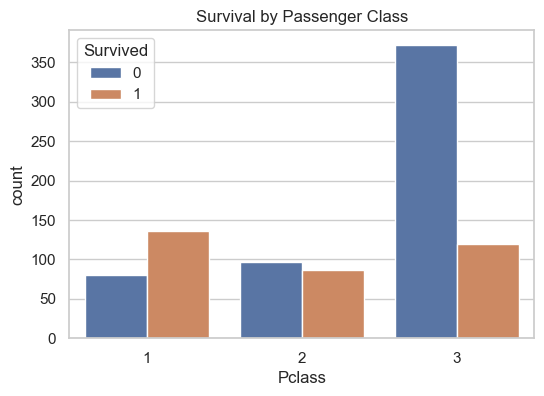

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.show()

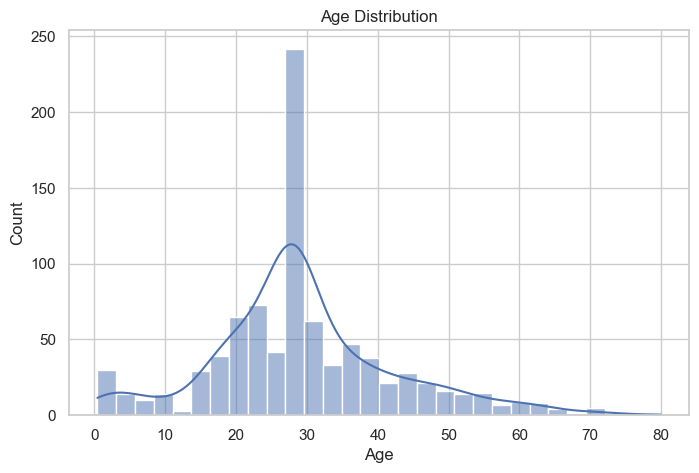

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

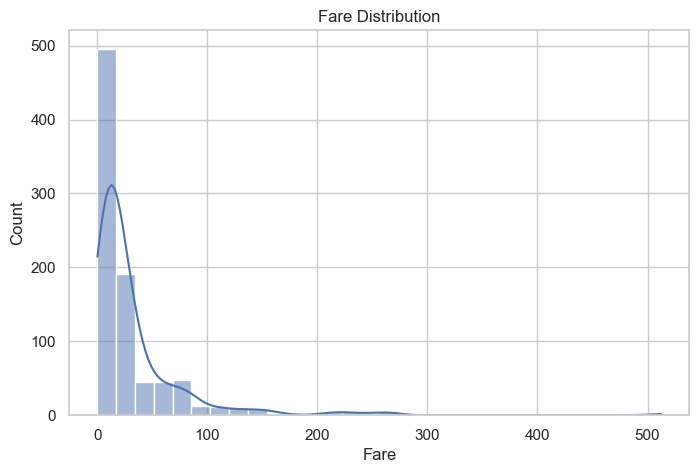

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["Fare"], bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

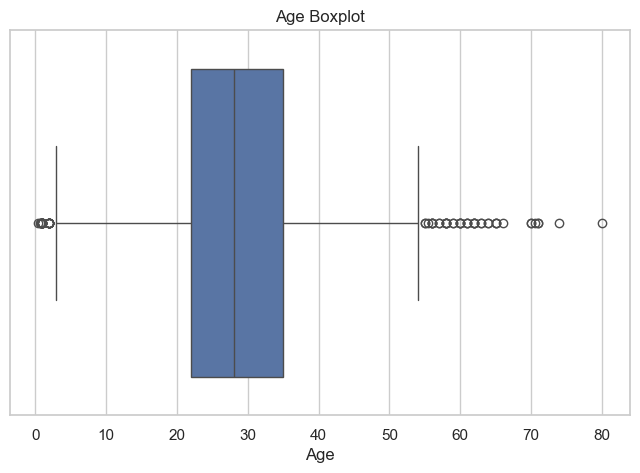

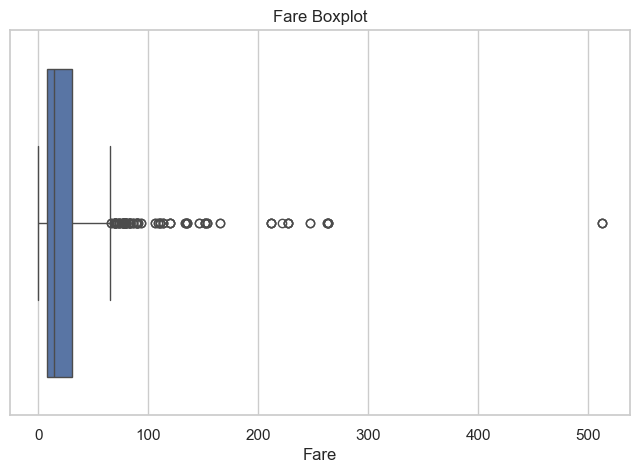

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Age"])
plt.title("Age Boxplot")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Fare"])
plt.title("Fare Boxplot")
plt.show()

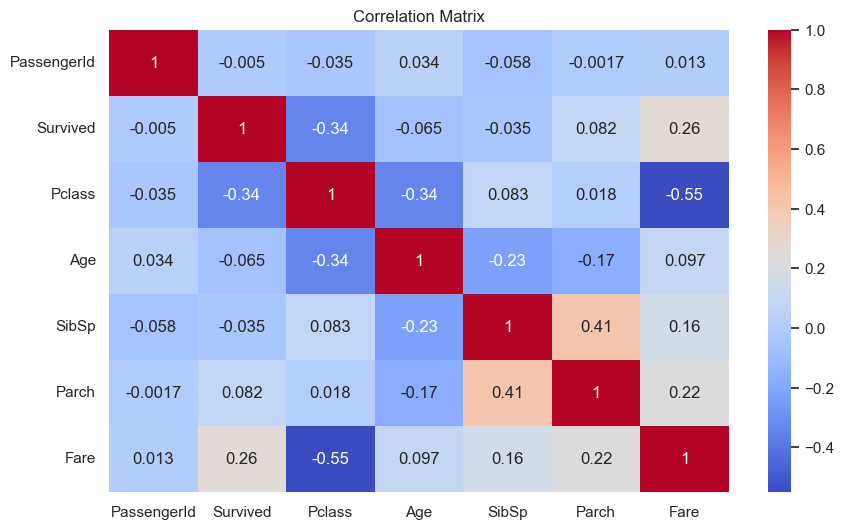

In [18]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

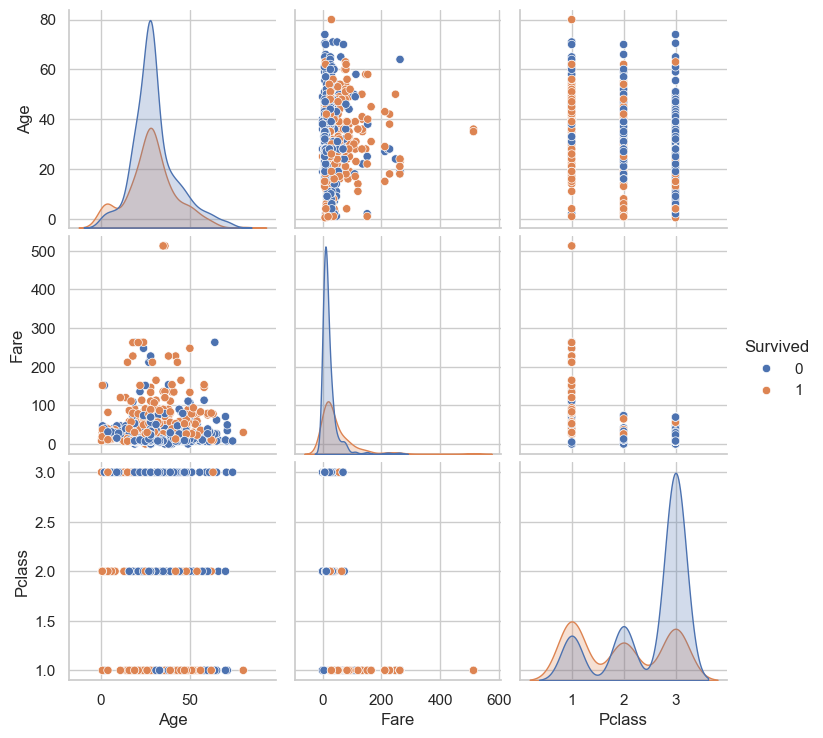

In [19]:
sns.pairplot(
    df[["Survived","Age","Fare","Pclass"]],
    hue="Survived"
)

plt.show()

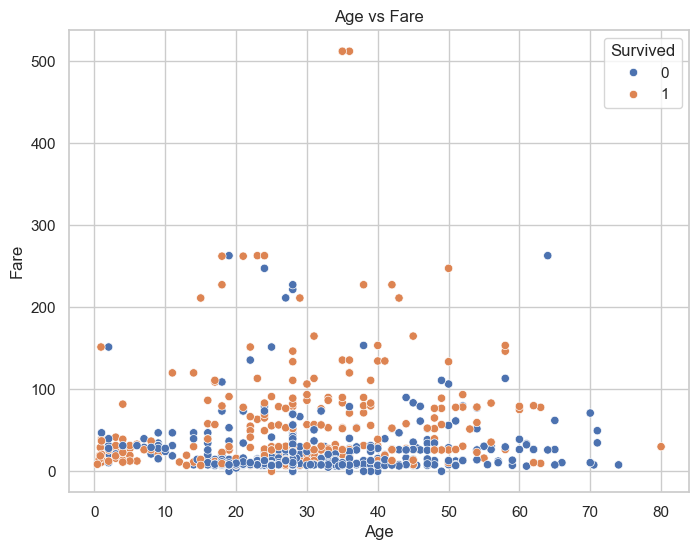

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Survived"
)

plt.title("Age vs Fare")
plt.show()

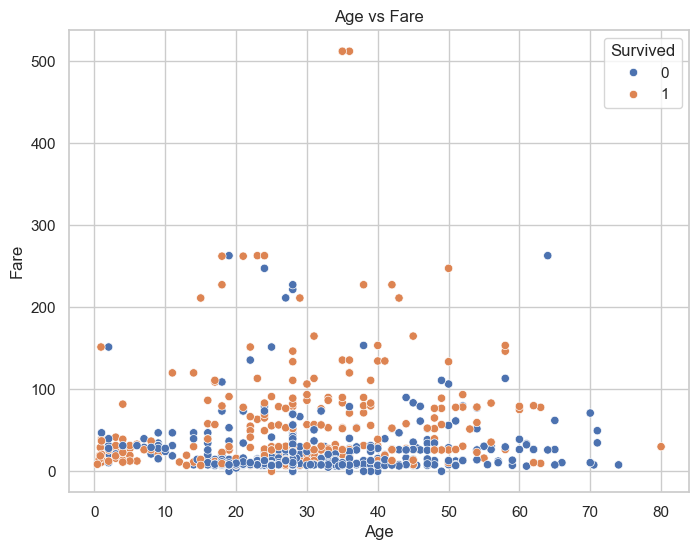

In [22]:
survival = df["Survived"].value_counts(normalize=True) * 100

print(survival)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [23]:
print("========== EDA INSIGHTS ==========")

print("1. Female passengers had a higher survival rate than male passengers.")

print("2. First-class passengers were more likely to survive.")

print("3. Most passengers were between 20 and 40 years old.")

print("4. Fare distribution is right-skewed with several outliers.")

print("5. Cabin contained many missing values and was removed.")

print("6. Missing Age values were replaced using the median.")

print("7. Fare has significant outliers.")

print("8. Survival is positively associated with passenger class and gender.")

========== EDA INSIGHTS ==========
1. Female passengers had a higher survival rate than male passengers.
2. First-class passengers were more likely to survive.
3. Most passengers were between 20 and 40 years old.
4. Fare distribution is right-skewed with several outliers.
5. Cabin contained many missing values and was removed.
6. Missing Age values were replaced using the median.
7. Fare has significant outliers.
8. Survival is positively associated with passenger class and gender.
